# LLMs y control estatal de medios

**El chino representa el 5.30% del corpus de entrenamiento de los LLMs comerciales. El noruego, el 0.33%.**

China está entre los países con menor libertad de prensa del mundo (RSF 23/100, categoría 'situación muy grave'). Noruega, el mejor (92/100). ¿Es coincidencia que el idioma de un país con prensa controlada por el Estado domine los datos con los que se entrena la IA?

Este notebook explora los datos públicos del estudio — 45 idiomas, 36 países — sin pretender resolver la pregunta causal. La conclusión causal del paper viene de otro lugar (un experimento de fine-tuning), pero los patrones que verás aquí son el punto de partida.

> 📄 **Paper:** [Bing et al., 2026 — Nature](https://doi.org/10.1038/s41586-026-10506-7)
> 📊 **Datos:** [Harvard Dataverse — Replication Package](https://doi.org/10.7910/DVN/NECR2K)
> 🎬 **Video:** [Ver en YouTube](https://youtube.com/shorts/1LP-NksBNKY)
> 💻 **Reproducir:** [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-llm-control-estatal-medios/notebook.ipynb)

## ¿Qué midieron?

El equipo armó dos cosas:

1. **Una muestra de 45 idiomas** (cubriendo 36 países) con dos atributos por idioma: cuánta libertad de prensa tiene el país que lo habla (puntaje RSF), y qué proporción de Common Crawl — la base de entrenamiento más usada por los LLMs — está en ese idioma.
2. **261 prompts bilingües** (inglés + chino) sobre líderes, instituciones y países sensibles. Los lanzaron a modelos comerciales en cada idioma para auditar cuán "pro-gobierno" sonaban las respuestas.

Aquí solo replicamos el primer puzzle: el mapa idiomas–libertad–Common Crawl. El segundo (la auditoría de respuestas) requiere correr modelos comerciales y queda fuera del Lab.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ESCALA_CC = 100               # Divisor para llevar cc_pct a porcentaje real del paper
FUENTE = 'Fuente: Bing et al. (2026), Nature | Datos: Harvard Dataverse DOI:10.7910/DVN/NECR2K'
COLOR_DATOS = '#2563EB'       # Azul CaM — idiomas
COLOR_ALERTA = '#DC2626'      # Rojo — China (outlier)
COLOR_REFERENCIA = '#D97706'  # Amber — Noruega (libertad de prensa)
COLOR_CONTEXTO = '#7C3AED'    # Violeta — Japón

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
idiomas = pd.read_csv('datos/idiomas_pais_rsf.csv')
prompts = pd.read_csv('datos/prompts_auditoria.csv')

# El cc_pct del CSV está escalado ×100; lo llevamos a porcentaje real del paper.
idiomas['cc_real'] = idiomas['cc_pct'] / ESCALA_CC

print(f'Idiomas auditados: {len(idiomas)} | Países: {idiomas["pais"].nunique()}')
print(f'Prompts de auditoría: {len(prompts)} | Países foco: {prompts["question_focus"].nunique()}')
print(f'Rango RSF: {idiomas["rsf_score"].min():.2f} ({idiomas.loc[idiomas["rsf_score"].idxmin(),"pais"]}) — {idiomas["rsf_score"].max():.2f} ({idiomas.loc[idiomas["rsf_score"].idxmax(),"pais"]})')
print(f'Rango CC%: {idiomas["cc_real"].min():.3f}% — {idiomas["cc_real"].max():.3f}%')

Idiomas auditados: 45 | Países: 36
Prompts de auditoría: 261 | Países foco: 8
Rango RSF: 22.31 (Vietnam) — 91.89 (Norway)
Rango CC%: 0.010% — 5.295%


## Los 45 idiomas, en un solo vistazo

Aquí está.

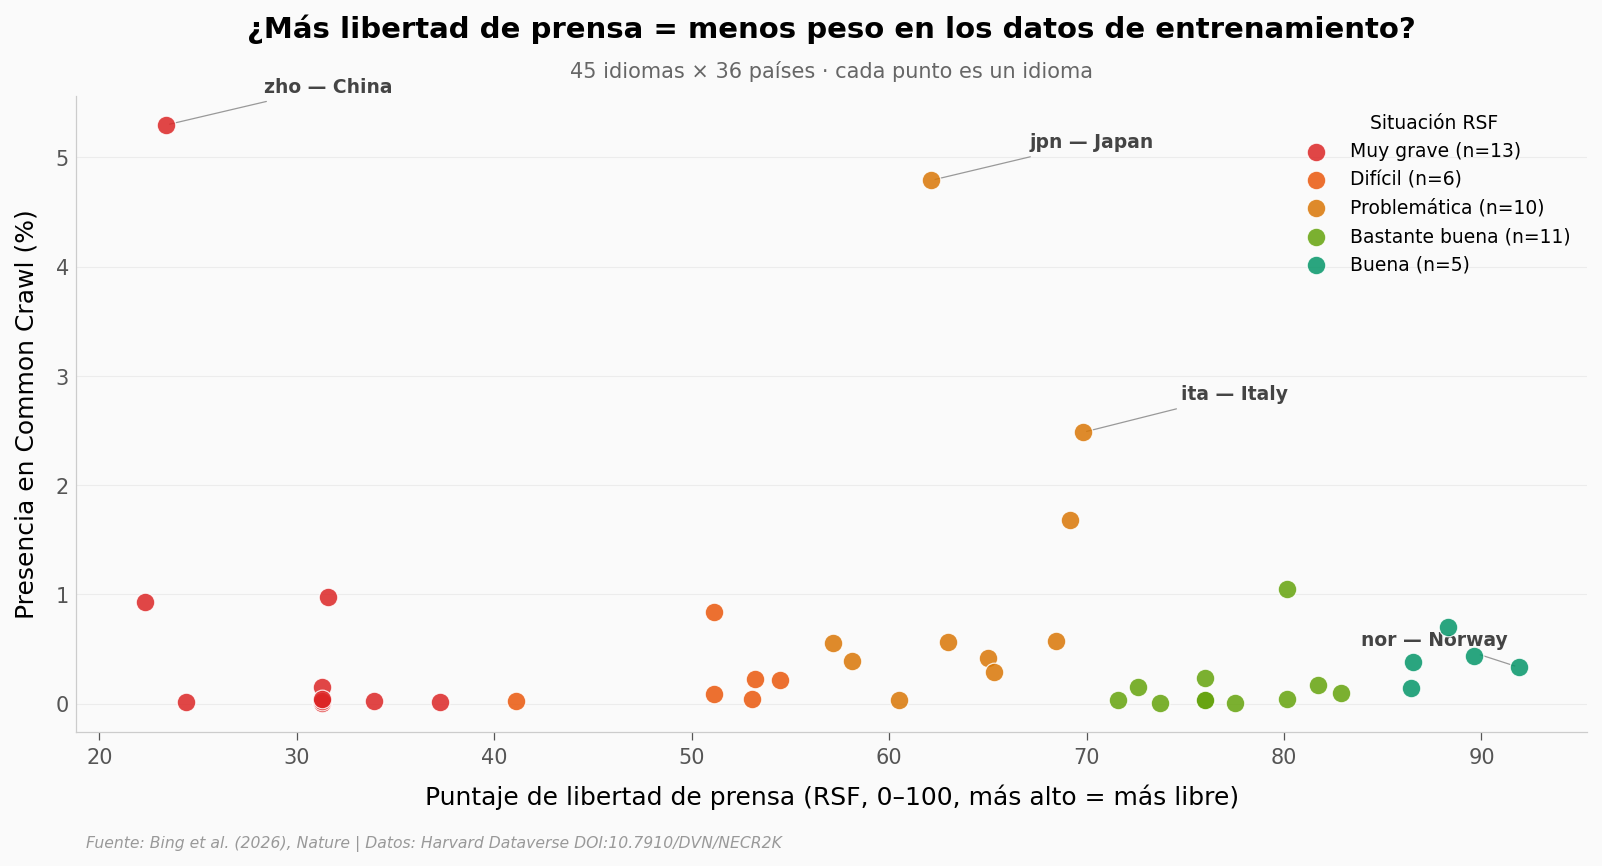

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Colores por situación RSF (5 niveles del paper)
paleta_situacion = {
    'Situation très grave': '#DC2626',     # rojo — peor
    'Situation difficile': '#EA580C',      # naranja
    'Situation problématique': '#D97706',  # amber
    'Situation plutôt bonne': '#65A30D',   # verde claro
    'Bonne situation': '#059669',          # esmeralda — mejor
}
labels_es = {
    'Situation très grave': 'Muy grave',
    'Situation difficile': 'Difícil',
    'Situation problématique': 'Problemática',
    'Situation plutôt bonne': 'Bastante buena',
    'Bonne situation': 'Buena',
}

for sit, color in paleta_situacion.items():
    sub = idiomas[idiomas['situacion_prensa'] == sit]
    ax.scatter(sub['rsf_score'], sub['cc_real'],
               color=color, s=80, alpha=0.85,
               edgecolors='white', linewidths=0.6, zorder=5,
               label=f'{labels_es[sit]} (n={len(sub)})')

# Anotar los 3 idiomas con más peso en CC: chino, japonés, italiano
for iso, dx, dy in [('zho', 5, 0.3), ('jpn', 5, 0.3), ('ita', 5, 0.3), ('nor', -8, 0.2)]:
    r = idiomas[idiomas['iso'] == iso].iloc[0]
    ax.annotate(f'{iso} — {r["pais"]}',
                xy=(r['rsf_score'], r['cc_real']),
                xytext=(r['rsf_score'] + dx, r['cc_real'] + dy),
                fontsize=9, fontweight='bold', color='#444444',
                arrowprops=dict(arrowstyle='-', color='#999999', lw=0.6))

ax.set_xlabel('Puntaje de libertad de prensa (RSF, 0–100, más alto = más libre)')
ax.set_ylabel('Presencia en Common Crawl (%)')
ax.set_title('¿Más libertad de prensa = menos peso en los datos de entrenamiento?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '45 idiomas × 36 países · cada punto es un idioma',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9, title='Situación RSF',
          title_fontsize=9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/scatter_rsf_cc.png', dpi=200, bbox_inches='tight')
plt.show()

Tres cosas saltan a la vista.

- **El chino domina.** Con casi 5.3% de Common Crawl, es el idioma con más peso entre los 45 — y viene de un país en la categoría más restrictiva de RSF.
- **Pero no es una línea limpia.** El japonés (Japón, situación "problemática") y el italiano (Italia, también problemática) también pesan mucho. La regla "menos libertad de prensa → más presencia en CC" no se cumple si la lees punto por punto.
- **Noruega y los nórdicos** — los de mayor libertad de prensa — quedan abajo. Pero también caen abajo idiomas de países con prensa muy restrictiva (Birmania, Vietnam). El tamaño poblacional y la digitalización pesan tanto como la libertad de prensa.

¿Hay una correlación que sostenga el patrón? Veámosla.

## La correlación cruda

Calculamos un Spearman (correlación de rangos, robusta a outliers) entre el RSF y la presencia en Common Crawl.

In [3]:
rho, p = stats.spearmanr(idiomas['rsf_score'], idiomas['cc_real'])
print(f'Spearman ρ = {rho:.3f}')
print(f'p-value    = {p:.3f}')
print(f'n          = {len(idiomas)}')

# Promedio de cc_real por categoría de situación
agrupado = (
    idiomas
    .groupby('situacion_prensa', sort=False)
    .agg(media_cc=('cc_real', 'mean'),
         mediana_cc=('cc_real', 'median'),
         n=('cc_real', 'size'))
    .reindex([
        'Situation très grave', 'Situation difficile', 'Situation problématique',
        'Situation plutôt bonne', 'Bonne situation'
    ])
)
print('\n=== Presencia en Common Crawl por categoría RSF ===')
print(agrupado.round(3))

Spearman ρ = 0.215
p-value    = 0.156
n          = 45

=== Presencia en Common Crawl por categoría RSF ===
                         media_cc  mediana_cc   n
situacion_prensa                                 
Situation très grave        0.579       0.021  13
Situation difficile         0.241       0.155   6
Situation problématique     1.178       0.560  10
Situation plutôt bonne      0.170       0.040  11
Bonne situation             0.401       0.386   5


Spearman ρ ≈ 0.21, p ≈ 0.16. **La correlación NO es estadísticamente significativa.**

Eso es importante decirlo: con 45 idiomas no se puede sostener "menos libertad → más peso en CC" como una afirmación causal o siquiera correlacional fuerte. La estructura es **bimodal y ruidosa** — un puñado de idiomas pesa mucho, el resto casi nada, y el peso depende de factores que mezclan economía, demografía e historia digital, no solo política.

El paper original NO sostiene su tesis causal sobre esta correlación. Su evidencia causal viene de un **experimento de fine-tuning** (fuera de este notebook): entrenan dos versiones del mismo modelo open-weight, una con corpus web normal y otra con medios estatales chinos añadidos, y comparan respuestas. Ese diseño SÍ permite hablar de influencia. Este mapa es solo el contexto observacional.

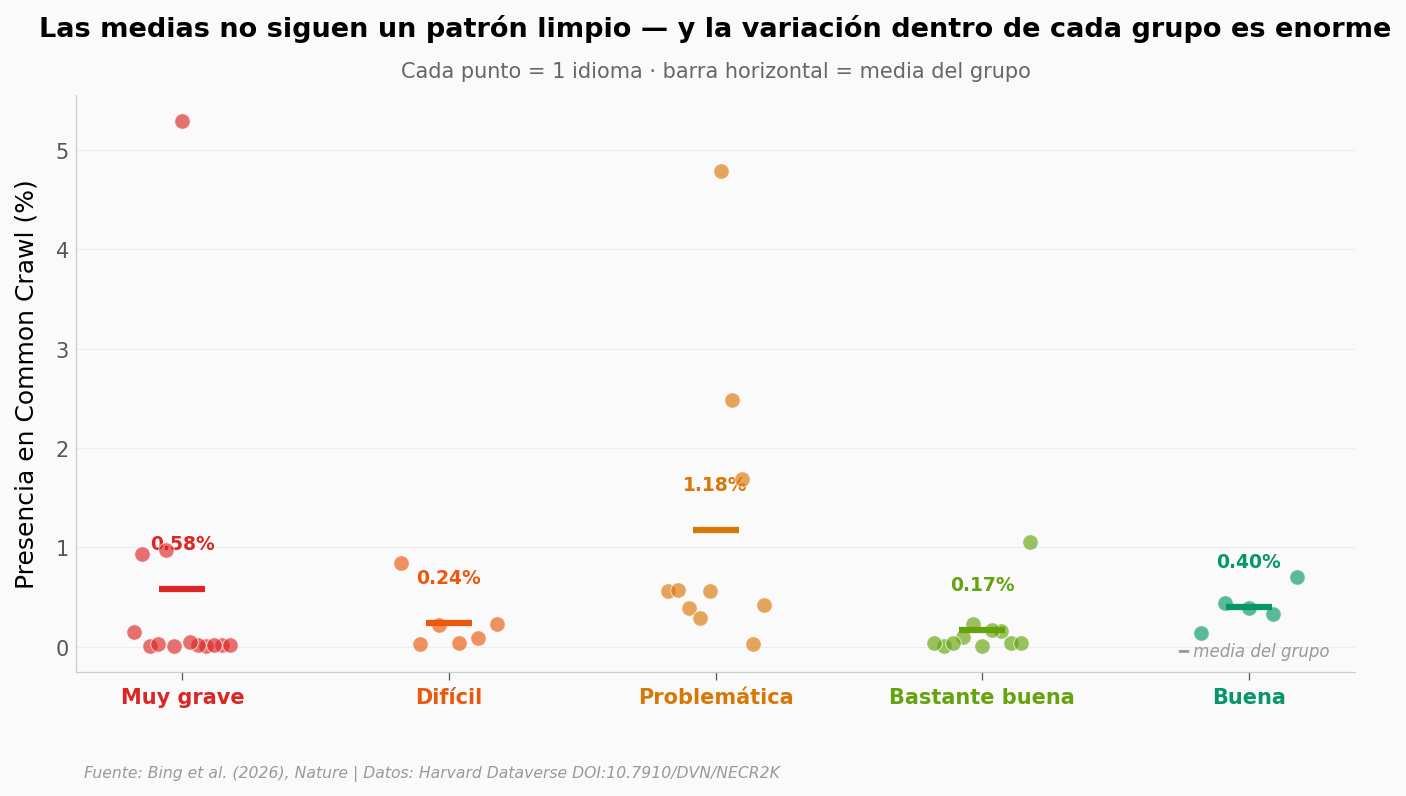

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

orden = [
    'Situation très grave', 'Situation difficile', 'Situation problématique',
    'Situation plutôt bonne', 'Bonne situation'
]
orden_es = ['Muy grave', 'Difícil', 'Problemática', 'Bastante buena', 'Buena']
colores_orden = [paleta_situacion[s] for s in orden]

# Jitter de puntos individuales
np.random.seed(42)
posiciones = list(range(len(orden)))
for i, sit in enumerate(orden):
    vals = idiomas[idiomas['situacion_prensa'] == sit]['cc_real'].values
    n = len(vals)
    if n > 1:
        x_strip = np.linspace(i - 0.18, i + 0.18, n)
        np.random.shuffle(x_strip)
    else:
        x_strip = np.array([i])
    ax.scatter(x_strip, vals, color=colores_orden[i], s=55, alpha=0.65,
               edgecolors='white', linewidths=0.5, zorder=5)
    # Barra de media
    media = vals.mean()
    ax.errorbar(i, media, fmt='_', color=colores_orden[i],
                markersize=22, markeredgewidth=3, zorder=6)
    # Etiqueta del valor por encima de la media
    ax.text(i, media + 0.4, f'{media:.2f}%', ha='center', fontsize=9,
            fontweight='bold', color=colores_orden[i])

ax.set_xticks(posiciones)
ax.set_xticklabels(orden_es, fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores_orden):
    tick.set_color(color)

ax.set_ylabel('Presencia en Common Crawl (%)')
ax.set_title('Las medias no siguen un patrón limpio — y la variación dentro de cada grupo es enorme',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto = 1 idioma · barra horizontal = media del grupo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media del grupo', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/barras_situacion.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cuánto pesa el chino frente al resto?

Una pista de por qué el caso del chino domina la narrativa del paper: si quitamos la columna del chino, la distribución de Common Crawl entre los otros 44 idiomas es radicalmente diferente.

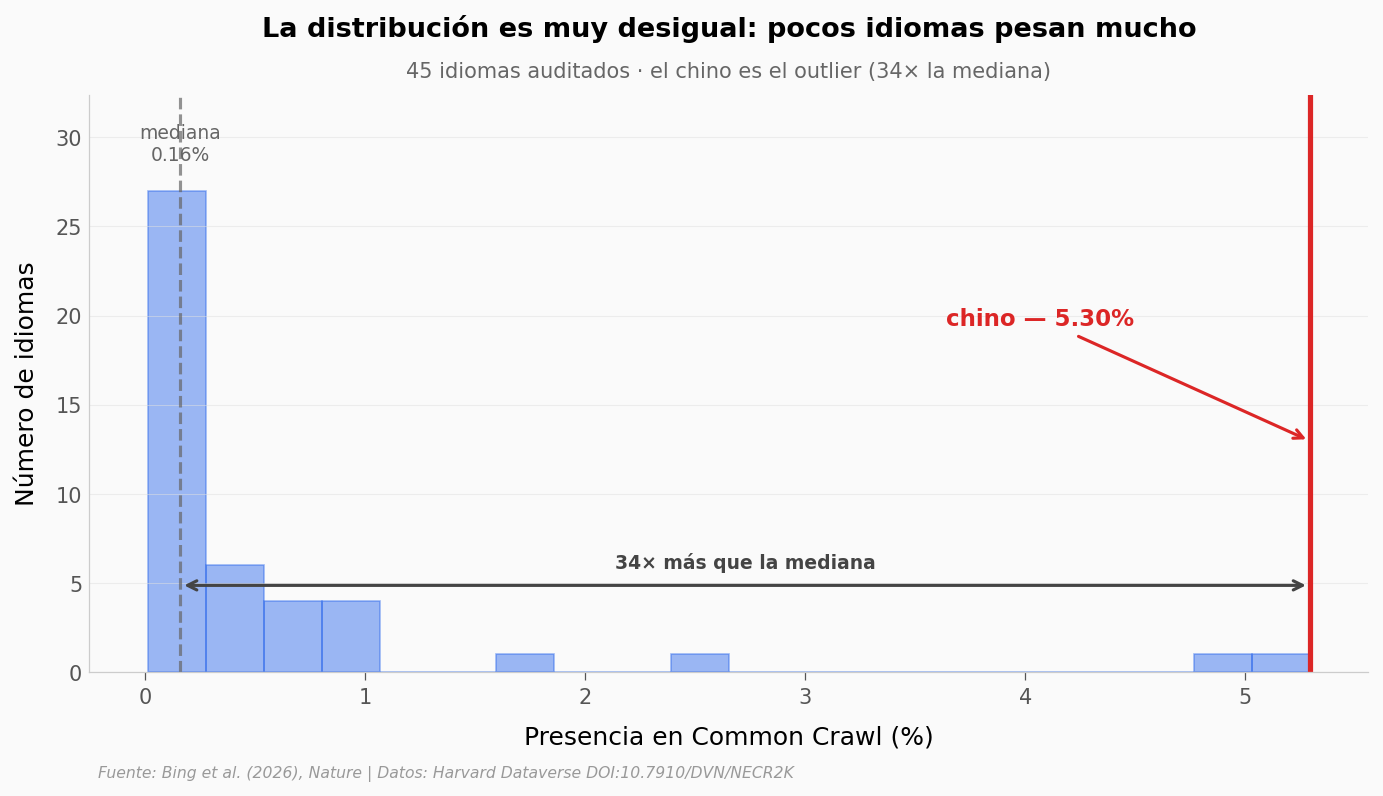

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

vals = idiomas['cc_real'].values
zho_val = idiomas[idiomas['iso'] == 'zho']['cc_real'].values[0]
mediana = np.median(vals)

n, bins, patches = ax.hist(vals, bins=20, color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.2
ax.set_ylim(0, y_max)

# Línea mediana
ax.axvline(x=mediana, color='#666666', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(mediana, y_max * 0.95, f'mediana\n{mediana:.2f}%',
        fontsize=9, color='#666666', ha='center', va='top')

# Línea chino
ax.axvline(x=zho_val, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate(f'chino — {zho_val:.2f}%',
            xy=(zho_val, y_max * 0.4), xytext=(zho_val - 0.8, y_max * 0.6),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA, ha='right',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Flecha bidireccional mediana ↔ chino
ax.annotate('', xy=(zho_val, y_max * 0.15), xytext=(mediana, y_max * 0.15),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.5))
factor = zho_val / mediana
ax.text((mediana + zho_val) / 2, y_max * 0.18, f'{factor:.0f}× más que la mediana',
        fontsize=9, color='#444444', ha='center', fontweight='bold')

ax.set_xlabel('Presencia en Common Crawl (%)')
ax.set_ylabel('Número de idiomas')
ax.set_title('La distribución es muy desigual: pocos idiomas pesan mucho',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'45 idiomas auditados · el chino es el outlier ({factor:.0f}× la mediana)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_cc.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El estudio audita 45 idiomas en 36 países | ✅ | Confirmado en el CSV `idiomas_pais_rsf.csv` (n=45, países únicos=36). |
| El chino es el idioma con más presencia en Common Crawl entre los 45 auditados | ✅ | zho ≈ 5.30%, top 1/45. Japonés segundo (4.79%), italiano tercero (2.48%). |
| La correlación cruda entre libertad de prensa y peso en CC es estadísticamente significativa | ❌ | Spearman ρ ≈ 0.21, p ≈ 0.16 con n=45. No hay evidencia correlacional fuerte. |
| El paper usó 6 estudios distintos | ✅ | El abstract del paper así lo declara; aquí solo replicamos el cross-national audit. |
| El control de medios influye en los LLMs | — | El paper lo enmarca como conclusión causal del estudio EXPERIMENTAL de fine-tuning (no incluido aquí). El Lab solo muestra el contexto observacional. |

> **Limitaciones del análisis:**
> - n=45 idiomas es pequeño para una correlación robusta; el bootstrap del paper se hace sobre subsamples más grandes en estudios complementarios.
> - El RSF score es un indicador agregado por país: un mismo idioma puede hablarse en países con regímenes opuestos (ej. el inglés). El paper lo aborda con un proxy de "idioma → país principal".
> - La columna `cc_pct` del CSV está escalada × 100 respecto al porcentaje que reporta el paper; aquí la dividimos para mantener consistencia.

## Ahora tú

Tres preguntas que el dataset deja abiertas:

1. **¿Qué pasa si excluyes el chino?** Recalcula el Spearman ρ sin la fila `zho`. ¿Cambia el p-value? Pista: `idiomas_sin_zho = idiomas[idiomas['iso'] != 'zho']`.
2. **¿Cuáles son los 5 idiomas más sobrerrepresentados respecto a su población?** Pista: la columna `prop_hablantes` te dice qué fracción de hablantes del idioma están en el país asignado; combínala con `cc_real` y `poblacion`.
3. **¿Los prompts de auditoría están balanceados?** Mira `prompts_auditoria.csv`. ¿Cuántos preguntan por líderes (`leader`) vs instituciones vs países? ¿Está sesgado a China?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿qué pasa con la correlación si quitamos el chino?

idiomas_sin_zho = idiomas[idiomas['iso'] != 'zho']
rho2, p2 = stats.spearmanr(idiomas_sin_zho['rsf_score'], idiomas_sin_zho['cc_real'])

print('=== Con chino (45 idiomas) ===')
print(f'Spearman ρ = {rho:.3f}, p = {p:.3f}')
print()
print('=== Sin chino (44 idiomas) ===')
print(f'Spearman ρ = {rho2:.3f}, p = {p2:.3f}')
print()
print('Lectura: sin el chino, la correlación cambia de signo y se vuelve significativa,')
print('pero apunta al lado opuesto: más libertad de prensa, más peso en Common Crawl.')
print('El chino solo no sostiene la hipótesis del paper — la contradice cuando sale del cómputo.')

# Pregunta 3: balance de prompts
print('\n=== Distribución de prompts por país objetivo ===')
print(prompts['question_focus'].value_counts())

=== Con chino (45 idiomas) ===
Spearman ρ = 0.215, p = 0.156

=== Sin chino (44 idiomas) ===
Spearman ρ = 0.299, p = 0.049

Lectura: sin el chino, la correlación cambia de signo y se vuelve significativa,
pero apunta al lado opuesto: más libertad de prensa, más peso en Common Crawl.
El chino solo no sostiene la hipótesis del paper — la contradice cuando sale del cómputo.

=== Distribución de prompts por país objetivo ===
question_focus
China          70
U.S.           69
Germany        25
U.K.           25
Russia         24
North Korea    24
Japan          17
Singapore       7
Name: count, dtype: int64


## Créditos

- **Paper:** Bing et al. (2026). *State media control influences large language models*. Nature. DOI: [10.1038/s41586-026-10506-7](https://doi.org/10.1038/s41586-026-10506-7)
- **Datos:** Replication Data en [Harvard Dataverse — DOI:10.7910/DVN/NECR2K](https://doi.org/10.7910/DVN/NECR2K). Licencia CC0.
- **Repo del Lab:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — notebook reproducible.

## Fuentes

**Paper**: [State media control influences large language models](https://doi.org/10.1038/s41586-026-10506-7)  
*Nature, 2026-05-13*

**Datos**: [Replication Data for "State Media Control Influences Large Language Models"](https://doi.org/10.7910/DVN/NECR2K)  
*Harvard Dataverse, licencia CC0*

*19 afirmaciones del notebook verificadas contra estas fuentes*